# Mathemagicland 2D Random Walk (Demo)

Based on the idea from:
https://www.instagram.com/mathemagiclandinsta/reel/DW2BveQklDj/

This notebook is intentionally short and parameter-driven.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils import (
    compute_planar_metrics,
    ensure_output_dirs,
    plot_histogram,
    plot_overlay_2d_solution_split,
    plot_single_walk_2d,
    run_cardinal_walk_trials,
    save_summary_csv,
    simulate_cardinal_walk_2d,
    split_paths_by_solution,
)

# Demo knobs: tweak these and rerun the notebook.
RANDOM_SEED = 42
N_TRIALS = 10
MAX_STEPS = 20_000

NOTEBOOK_DIR = Path('.')
OUTPUT_DIR, PATHS_DIR = ensure_output_dirs(NOTEBOOK_DIR / 'outputs' / 'mathemagicland_solution')

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(RANDOM_SEED)

print(f'Output folder: {OUTPUT_DIR.resolve()}')
print(f'RANDOM_SEED={RANDOM_SEED}, N_TRIALS={N_TRIALS}, MAX_STEPS={MAX_STEPS}')

Output folder: /home/manpazito/projects/fun_mini_sims/random_walks/outputs/mathemagicland_solution
RANDOM_SEED=42, N_TRIALS=10, MAX_STEPS=20000


## Walk Model

- Start at `(0, 0)`
- Each step picks one of 4 directions uniformly: right, up, left, down
- Stop at first return to `(0, 0)` after leaving it (or at `MAX_STEPS`)

## 1. Single Example Walk

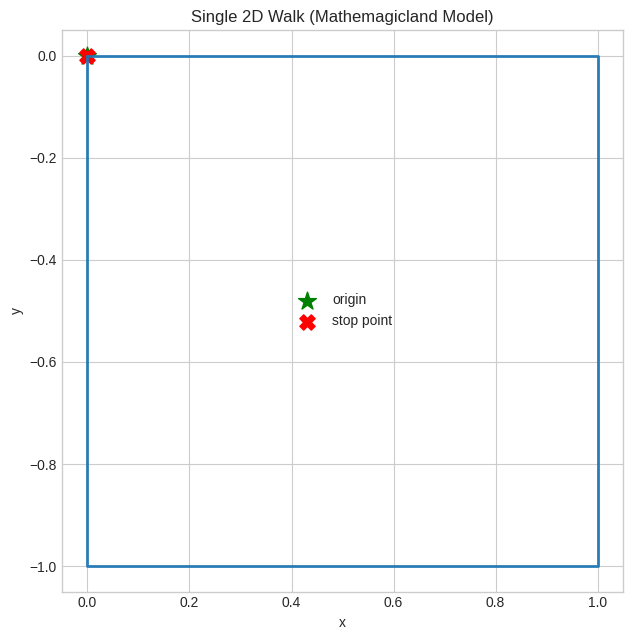

Single walk:
  steps_until_stop: 4
  returned_to_origin: True
  saved: outputs/mathemagicland_solution/single_walk.png


In [2]:
single_walk = simulate_cardinal_walk_2d(rng=rng, max_steps=MAX_STEPS)

single_walk_plot_path = OUTPUT_DIR / 'single_walk.png'
plot_single_walk_2d(
    xs=single_walk['xs'],
    ys=single_walk['ys'],
    out_path=single_walk_plot_path,
    title='Single 2D Walk (Mathemagicland Model)',
)

print('Single walk:')
print(f"  steps_until_stop: {single_walk['steps_until_stop']}")
print(f"  returned_to_origin: {single_walk['returned_to_origin']}")
print(f"  saved: {single_walk_plot_path}")

## 2. Monte Carlo Simulation

In [3]:
summary_df, all_paths = run_cardinal_walk_trials(
    rng=rng,
    n_trials=N_TRIALS,
    max_steps=MAX_STEPS,
    paths_dir=PATHS_DIR,
)

summary_csv_path = save_summary_csv(summary_df, OUTPUT_DIR / 'summary.csv')
metrics = compute_planar_metrics(summary_df, distance_col='max_distance')

print('Monte Carlo summary:')
print(f"  completed_trials: {metrics['completed_trials']}")
print(f"  censored_trials: {metrics['censored_trials']}")
print(f"  mean_return_time: {metrics['mean_return_time']:.3f}")
print(f"  mean_max_distance: {metrics['mean_max_distance']:.3f}")
print(f"  saved: {summary_csv_path}")

summary_df.head()

Monte Carlo summary:
  completed_trials: 6
  censored_trials: 4
  mean_return_time: 388.000
  mean_max_distance: 72.923
  saved: outputs/mathemagicland_solution/summary.csv


,trial_index,steps_until_stop,return_time,returned_to_origin,censored,max_distance,max_manhattan,bbox_width,bbox_height,bbox_area,final_x,final_y
0,0,2,2.0,True,False,1.000000,1,0,1,0,0,0
1,1,2,2.0,True,False,1.000000,1,1,0,0,0,0
2,2,70,70.0,True,False,7.280110,9,5,7,35,0,0
3,3,2246,2246.0,True,False,35.468296,50,38,47,1786,0,0
4,4,4,4.0,True,False,1.414214,2,1,1,1,0,0


## 3. Distribution Plots

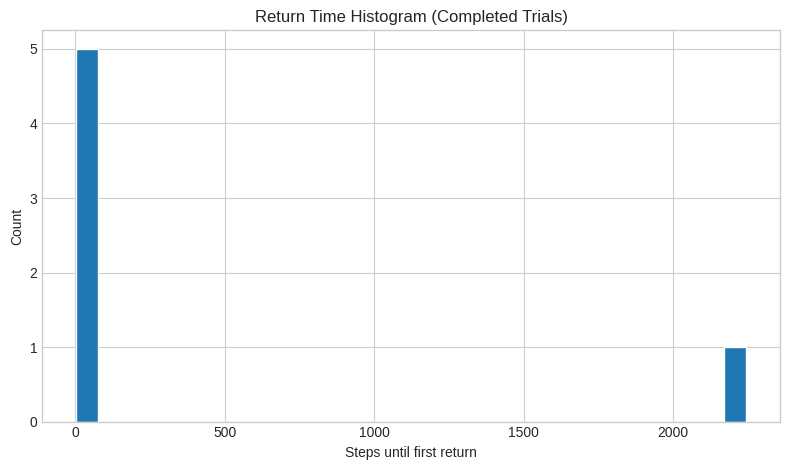

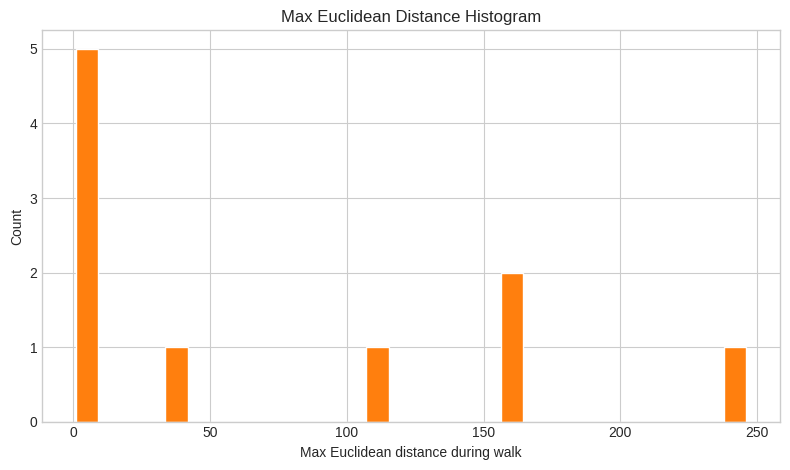

saved: outputs/mathemagicland_solution/return_time_histogram.png
saved: outputs/mathemagicland_solution/max_distance_histogram.png


In [4]:
completed_return_times = summary_df.loc[~summary_df['censored'], 'return_time']

return_hist_path = OUTPUT_DIR / 'return_time_histogram.png'
max_dist_hist_path = OUTPUT_DIR / 'max_distance_histogram.png'

plot_histogram(
    values=completed_return_times,
    out_path=return_hist_path,
    title='Return Time Histogram (Completed Trials)',
    xlabel='Steps until first return',
    color='tab:blue',
)

plot_histogram(
    values=summary_df['max_distance'],
    out_path=max_dist_hist_path,
    title='Max Euclidean Distance Histogram',
    xlabel='Max Euclidean distance during walk',
    color='tab:orange',
)

print(f'saved: {return_hist_path}')
print(f'saved: {max_dist_hist_path}')

## 4. Final Overlay Plot

Left panel: walks that returned to origin.
Right panel: censored walks.

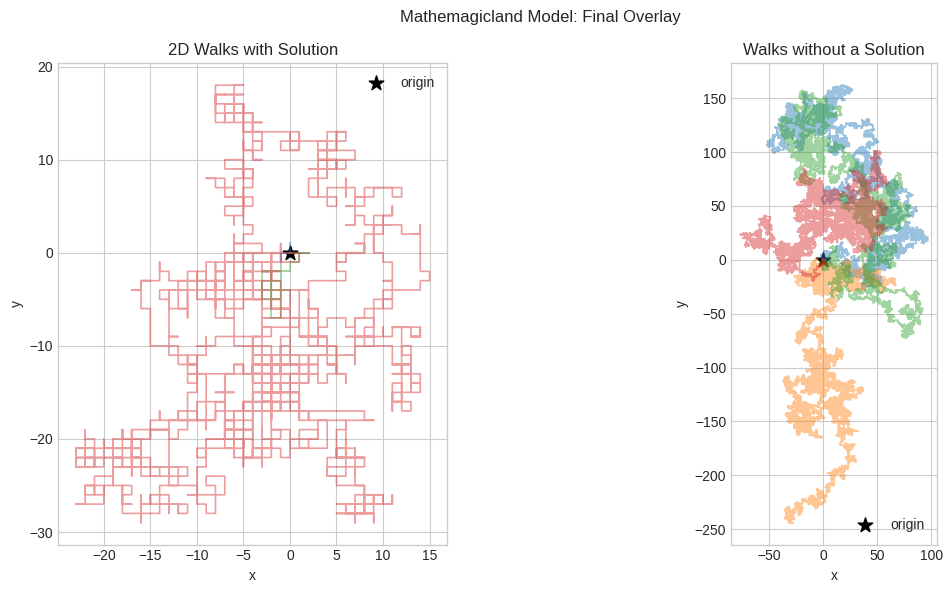

with_solution=6, without_solution=4
saved: outputs/mathemagicland_solution/overlay_walks.png


In [5]:
paths_with_solution, paths_without_solution = split_paths_by_solution(all_paths, summary_df)

overlay_path = OUTPUT_DIR / 'overlay_walks.png'
plot_overlay_2d_solution_split(
    paths_with_solution=paths_with_solution,
    paths_without_solution=paths_without_solution,
    out_path=overlay_path,
    left_title='2D Walks with Solution',
    right_title='Walks without a Solution',
    figure_title='Mathemagicland Model: Final Overlay',
)

print(f'with_solution={len(paths_with_solution)}, without_solution={len(paths_without_solution)}')
print(f'saved: {overlay_path}')